In [22]:
import pandas as pd

# Synthesizing a realistic Opta tactical sequence with Qualifier lists
opta_data = [
    {"id": 2001, "type_id": 1, "outcome": 1, "team": "City", "player": "Rodri", "x": 35.2, "y": 48.1, "qualifiers": [1, 140, 3]}, # Ground Pass, Pass Value, Defensive Third
    {"id": 2002, "type_id": 1, "outcome": 1, "team": "City", "player": "De Bruyne", "x": 58.4, "y": 22.0, "qualifiers": [1, 141]}, # Ground Pass, Middle Third
    {"id": 2003, "type_id": 1, "outcome": 1, "team": "City", "player": "Foden", "x": 72.1, "y": 15.5, "qualifiers": [1, 141, 287]}, # Under Pressure
    {"id": 2004, "type_id": 1, "outcome": 0, "team": "City", "player": "Foden", "x": 75.0, "y": 18.0, "qualifiers": [2, 141]}, # Intercepted / Incomplete Pass
    {"id": 2005, "type_id": 7, "outcome": 1, "team": "United", "player": "Martinez", "x": 26.0, "y": 81.0, "qualifiers": [4]}, # Tackle, Won possession
    {"id": 2006, "type_id": 1, "outcome": 0, "team": "United", "player": "Martinez", "x": 28.5, "y": 79.5, "qualifiers": [3, 15]}, # Long Ball Clearance, Failed
    {"id": 2007, "type_id": 1, "outcome": 1, "team": "City", "player": "De Bruyne", "x": 70.2, "y": 25.1, "qualifiers": [1, 287]}, # Recovery & Pass under pressure
    {"id": 2008, "type_id": 1, "outcome": 1, "team": "City", "player": "Haaland", "x": 82.5, "y": 35.0, "qualifiers": [1, 5]}, # Lay-off pass, Inside Box
    {"id": 2009, "type_id": 1, "outcome": 1, "team": "City", "player": "De Bruyne", "x": 85.0, "y": 44.2, "qualifiers": [1, 155]}, # Assist / Intentional Key Pass
    {"id": 2010, "type_id": 16, "outcome": 1, "team": "City", "player": "Haaland", "x": 92.1, "y": 51.5, "qualifiers": [15, 20]} # Goal, Shot on target, Foot
]

# Convert to DataFrame
df_opta = pd.DataFrame(opta_data)
df_opta


,id,type_id,outcome,team,player,x,y,qualifiers
0,2001,1,1,City,Rodri,35.2,48.1,"[1, 140, 3]"
1,2002,1,1,City,De Bruyne,58.4,22.0,"[1, 141]"
2,2003,1,1,City,Foden,72.1,15.5,"[1, 141, 287]"
3,2004,1,0,City,Foden,75.0,18.0,"[2, 141]"
4,2005,7,1,United,Martinez,26.0,81.0,[4]
5,2006,1,0,United,Martinez,28.5,79.5,"[3, 15]"
6,2007,1,1,City,De Bruyne,70.2,25.1,"[1, 287]"
7,2008,1,1,City,Haaland,82.5,35.0,"[1, 5]"
8,2009,1,1,City,De Bruyne,85.0,44.2,"[1, 155]"
9,2010,16,1,City,Haaland,92.1,51.5,"[15, 20]"


In [24]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df_opta)

MessageError: Error: credential propagation was unsuccessful

decoded_events = []

for index, row in df_opta.iterrows():
    # Base event type mapping
    if row['type_id'] == 1:
        event_name = "Pass"
    elif row['type_id'] == 7:
        event_name = "Tackle"
    elif row['type_id'] == 16:
        event_name = "Goal!"
    else:
        event_name = "Other"
        
    # Analyze nested Qualifier flags
    is_under_pressure = "Yes" if 287 in row['qualifiers'] else "No"
    is_assist = "Yes" if 155 in row['qualifiers'] else "No"
    
    decoded_events.append({
        "Player": row['player'],
        "Team": row['team'],
        "Event": event_name,
        "Success": "Yes" if row['outcome'] == 1 else "No",
        "Under Pressure": is_under_pressure,
        "Is Assist": is_assist,
        "X": row['x']
    })

# Convert to clean overview table
df_decoded = pd.DataFrame(decoded_events)
df_decoded


In [28]:
# A line-breaking pass moves the ball forward into the final third (X > 66)
line_breakers = df_decoded[
    (df_decoded['Event'] == 'Pass') &
    (df_decoded['Success'] == 'Yes') &
    (df_decoded['Under Pressure'] == 'Yes') &
    (df_decoded['X'] > 50)
]

print("--- TACTICAL SCOUTING REPORT ---")
if not line_breakers.empty:
    print(line_breakers[['Player', 'Team', 'Under Pressure', 'X']])
else:
    print("No matches found.")


--- TACTICAL SCOUTING REPORT ---
      Player  Team Under Pressure     X
2      Foden  City            Yes  72.1
6  De Bruyne  City            Yes  70.2


In [29]:
# Expanded match event data including wide channel play
crossing_data = [
    {"player": "Foden", "action": "Pass", "success": "Yes", "x": 75.0, "y": 12.0},  # Deep cross from Left Flank
    {"player": "Foden", "action": "Pass", "success": "No", "x": 72.5, "y": 14.2},   # Blocked cross from Left Flank
    {"player": "Foden", "action": "Pass", "success": "Yes", "x": 45.0, "y": 20.0},  # Midfield backward pass
    {"player": "Walker", "action": "Pass", "success": "Yes", "x": 78.2, "y": 88.5}, # Deep cross from Right Flank
    {"player": "Walker", "action": "Pass", "success": "No", "x": 68.0, "y": 85.0},  # Overhit cross from Right Flank
    {"player": "Walker", "action": "Pass", "success": "Yes", "x": 82.1, "y": 91.0}  # Deep cross from Right Flank
]

import pandas as pd
df_cross = pd.DataFrame(crossing_data)

# Filter criteria: Action must be a Pass, must start deep (X > 70), and must be wide (Y < 25 OR Y > 75)
crosses = df_cross[
    (df_cross['action'] == 'Pass') &
    (df_cross['x'] > 70.0) &
    ((df_cross['y'] < 25.0) | (df_cross['y'] > 75.0))
]

print("--- ISOLATED WIDE CROSSES ---")
crosses


--- ISOLATED WIDE CROSSES ---


,player,action,success,x,y
0,Foden,Pass,Yes,75.0,12.0
1,Foden,Pass,No,72.5,14.2
3,Walker,Pass,Yes,78.2,88.5
5,Walker,Pass,Yes,82.1,91.0


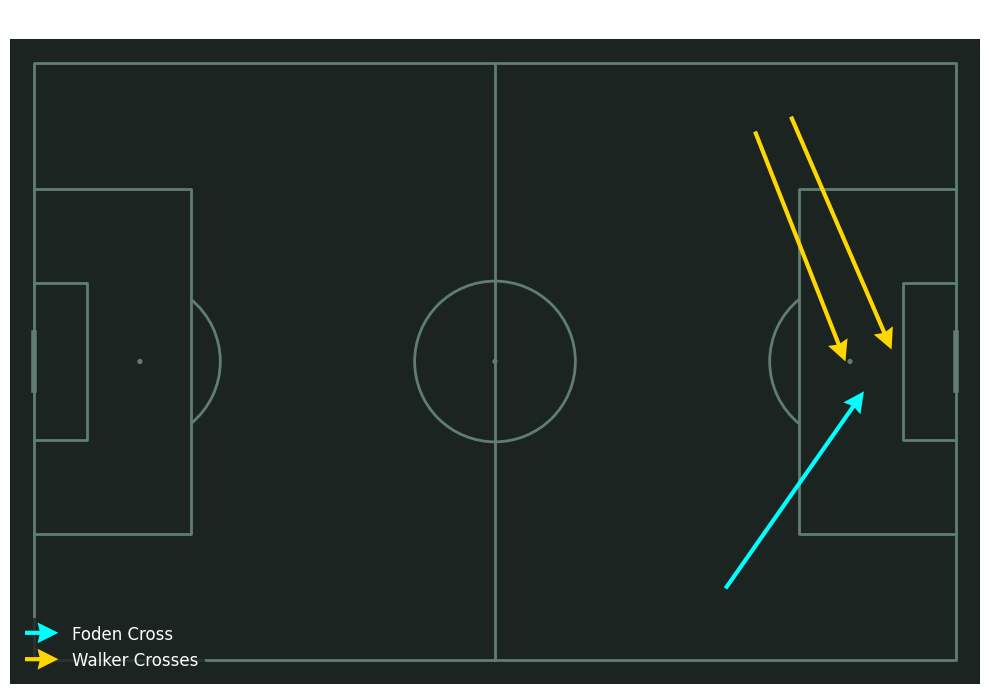

In [30]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Setup the Opta pitch grid
pitch = Pitch(pitch_type='opta', pitch_color='#1c2421', line_color='#607d72')
fig, ax = pitch.draw(figsize=(10, 7))

# 2. Draw Foden's Successful Cross (From Left Flank to Near Post)
# Coordinates: starts at (75, 12) -> ends at (90, 45)
pitch.arrows(75.0, 12.0, 90.0, 45.0, ax=ax, width=3, headwidth=5, color='cyan', label="Foden Cross")

# 3. Draw Walker's Two Successful Crosses (From Right Flank to Penalty Spot)
# Cross 1: (78.2, 88.5) -> (88.0, 50.0)
# Cross 2: (82.1, 91.0) -> (93.0, 52.0)
pitch.arrows(78.2, 88.5, 88.0, 50.0, ax=ax, width=3, headwidth=5, color='gold', label="Walker Crosses")
pitch.arrows(82.1, 91.0, 93.0, 52.0, ax=ax, width=3, headwidth=5, color='gold')

# 4. Customise the presentation
plt.legend(loc='lower left', fontsize=12, facecolor='#1c2421', edgecolor='none', labelcolor='white')
plt.title("City Successful Cross Delivery Zones", color='white', fontsize=16, pad=10)
plt.show()


In [31]:
import pandas as pd

# Synthesizing an Arsenal build-up sequence under a Liverpool high press
pressing_data = [
    {"id": 1, "team": "Arsenal", "action": "Pass", "success": "Yes", "x": 12.0, "y": 50.0}, # Pass deep in own box
    {"id": 2, "team": "Arsenal", "action": "Pass", "success": "Yes", "x": 25.5, "y": 22.0}, # Pass to Left-Back
    {"id": 3, "team": "Liverpool", "action": "Tackle", "success": "No", "x": 28.0, "y": 21.0}, # Liverpool presser misses tackle
    {"id": 4, "team": "Arsenal", "action": "Pass", "success": "Yes", "x": 32.1, "y": 28.5}, # Arsenal bypasses pressure
    {"id": 5, "team": "Arsenal", "action": "Pass", "success": "Yes", "x": 48.0, "y": 35.0}, # Pass near midfield
    {"id": 6, "team": "Liverpool", "action": "Interception", "success": "Yes", "x": 52.0, "y": 38.0} # Liverpool wins the ball back
]

df_press = pd.DataFrame(pressing_data)
df_press


,id,team,action,success,x,y
0,1,Arsenal,Pass,Yes,12.0,50.0
1,2,Arsenal,Pass,Yes,25.5,22.0
2,3,Liverpool,Tackle,No,28.0,21.0
3,4,Arsenal,Pass,Yes,32.1,28.5
4,5,Arsenal,Pass,Yes,48.0,35.0
5,6,Liverpool,Interception,Yes,52.0,38.0


In [32]:
# 1. Filter for events in the pressing zone (X < 60)
pressing_zone_data = df_press[df_press['x'] < 60.0]

# 2. Count Arsenal's passes in this zone
opponent_passes = len(pressing_zone_data[(pressing_zone_data['team'] == 'Arsenal') & (pressing_zone_data['action'] == 'Pass')])

# 3. Count Liverpool's defensive actions (Tackles + Interceptions) in this zone
defensive_actions = len(pressing_zone_data[
    (pressing_zone_data['team'] == 'Liverpool') &
    (pressing_zone_data['action'].isin(['Tackle', 'Interception']))
])

# 4. Calculate PPDA
ppda = opponent_passes / defensive_actions

print("--- PRESSING INTENSITY REPORT ---")
print(f"Arsenal Passes allowed: {opponent_passes}")
print(f"Liverpool Defensive Actions: {defensive_actions}")
print(f"Liverpool PPDA: {ppda}")


--- PRESSING INTENSITY REPORT ---
Arsenal Passes allowed: 4
Liverpool Defensive Actions: 2
Liverpool PPDA: 2.0


AttributeError: Quiver.set() got an unexpected keyword argument 'style'

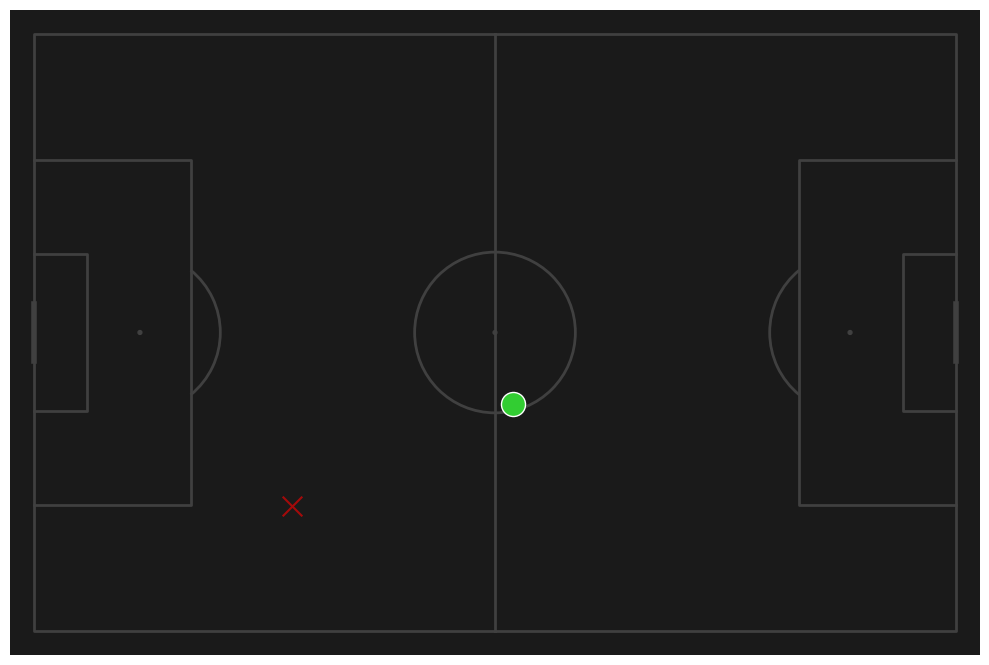

In [34]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Setup the pitch (We will make this one horizontal)
pitch = Pitch(pitch_type='opta', pitch_color='#1a1a1a', line_color='#404040')
fig, ax = pitch.draw(figsize=(10, 7))

# 2. Plot Liverpool's first defensive attempt (Missed Tackle at x=28, y=21)
pitch.scatter(28.0, 21.0, ax=ax, color='red', marker='x', s=200, alpha=0.6, label="Failed Pressing Action")

# 3. Plot Liverpool's successful high turnover (Interception at x=52, y=38)
pitch.scatter(52.0, 38.0, ax=ax, color='limegreen', marker='o', s=300, edgecolors='white', label="High Turnover (Possession Won)")

# 4. Draw an arrow showing how Arsenal tried to escape before the turnover
pitch.arrows(32.1, 28.5, 48.0, 35.0, ax=ax, width=2, headwidth=4, color='white', style='dashed', alpha=0.4)

# 5. Add titles and legend
plt.legend(loc='lower left', fontsize=11, facecolor='#1a1a1a', edgecolor='none', labelcolor='white')
plt.title("Liverpool High-Pressing Disruption Map", color='white', fontsize=16, pad=10)
plt.show()


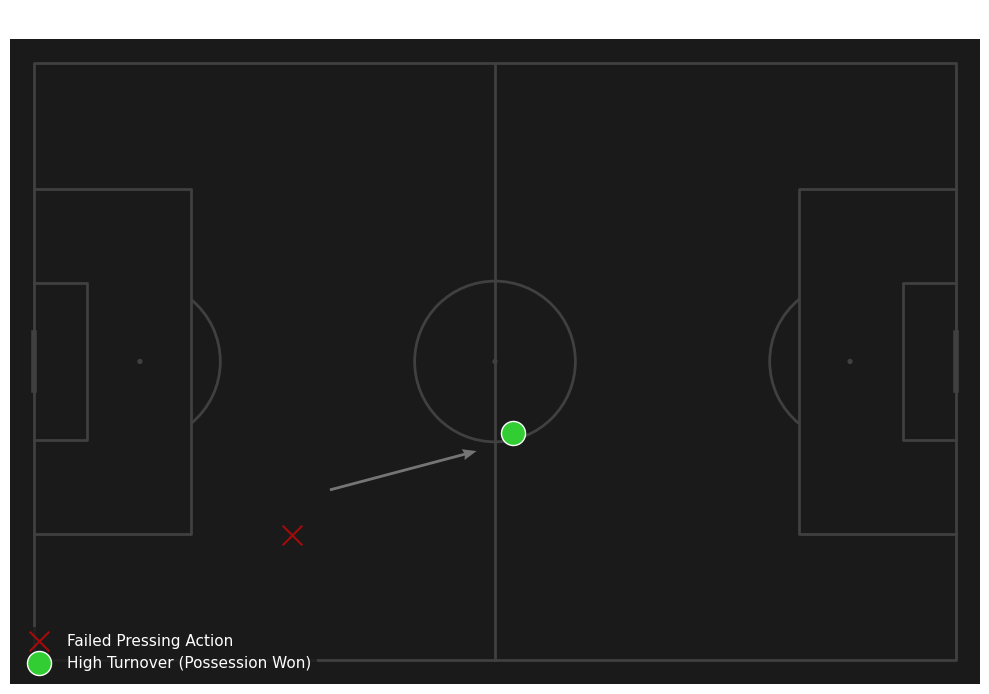

In [35]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Setup the pitch (Horizontal layout)
pitch = Pitch(pitch_type='opta', pitch_color='#1a1a1a', line_color='#404040')
fig, ax = pitch.draw(figsize=(10, 7))

# 2. Plot Liverpool's first defensive attempt (Missed Tackle at x=28, y=21)
pitch.scatter(28.0, 21.0, ax=ax, color='red', marker='x', s=200, alpha=0.6, label="Failed Pressing Action")

# 3. Plot Liverpool's successful high turnover (Interception at x=52, y=38)
pitch.scatter(52.0, 38.0, ax=ax, color='limegreen', marker='o', s=300, edgecolors='white', label="High Turnover (Possession Won)")

# 4. Draw an arrow showing how Arsenal tried to escape (Fixed: used linestyle)
pitch.arrows(32.1, 28.5, 48.0, 35.0, ax=ax, width=2, headwidth=4, color='white', linestyle='dashed', alpha=0.4)

# 5. Add titles and legend
plt.legend(loc='lower left', fontsize=11, facecolor='#1a1a1a', edgecolor='none', labelcolor='white')
plt.title("Liverpool High-Pressing Disruption Map", color='white', fontsize=16, pad=10)
plt.show()


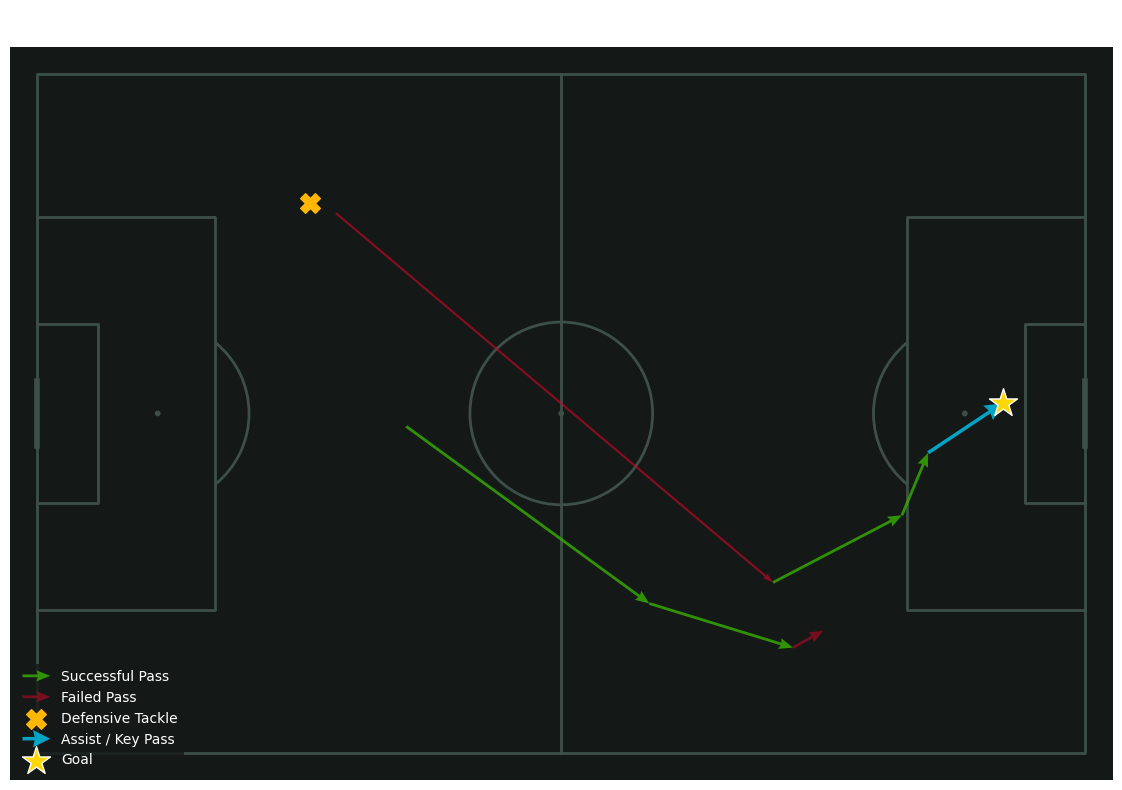

In [36]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Initialize the Opta 100x100 dark pitch grid
pitch = Pitch(pitch_type='opta', pitch_color='#141917', line_color='#3d4f48')
fig, ax = pitch.draw(figsize=(12, 8))

# 2. Draw the continuous passing chains (x_start, y_start, x_end, y_end)
# Rodri -> De Bruyne
pitch.arrows(35.2, 48.1, 58.4, 22.0, ax=ax, width=2, headwidth=4, color='#38b000', alpha=0.8, label="Successful Pass")
# De Bruyne -> Foden
pitch.arrows(58.4, 22.0, 72.1, 15.5, ax=ax, width=2, headwidth=4, color='#38b000', alpha=0.8)
# Foden incomplete pass (represented with a red arrow)
pitch.arrows(72.1, 15.5, 75.0, 18.0, ax=ax, width=2, headwidth=4, color='#d90429', alpha=0.5, label="Failed Pass")

# 3. Draw United's disruption phase
# Martinez Tackle attempt (x=26, y=81) - Note: In a real match, coordinates change based on possession shift direction
pitch.scatter(26.0, 81.0, ax=ax, color='#ffb703', marker='X', s=200, label="Defensive Tackle")
# Martinez failed long clearance
pitch.arrows(28.5, 79.5, 70.2, 25.1, ax=ax, width=1.5, headwidth=3, color='#d90429', linestyle='dotted', alpha=0.6)

# 4. Draw the final attacking phase leading to the goal
# De Bruyne Recovery Pass -> Haaland
pitch.arrows(70.2, 25.1, 82.5, 35.0, ax=ax, width=2, headwidth=4, color='#38b000', alpha=0.8)
# Haaland Lay-off -> De Bruyne
pitch.arrows(82.5, 35.0, 85.0, 44.2, ax=ax, width=2, headwidth=4, color='#38b000', alpha=0.8)
# De Bruyne Assist Pass -> Haaland
pitch.arrows(85.0, 44.2, 92.1, 51.5, ax=ax, width=2.5, headwidth=5, color='#00b4d8', alpha=0.9, label="Assist / Key Pass")

# 5. Plot the final Goal! (Gold Star)
pitch.scatter(92.1, 51.5, ax=ax, color='gold', marker='*', s=450, edgecolors='white', zorder=5, label="Goal")

# 6. Customize aesthetic styling and labels
plt.legend(loc='lower left', fontsize=10, facecolor='#141917', edgecolor='none', labelcolor='white')
plt.title("Manchester City Attacking Build-up & Goal Sequence", color='white', fontsize=16, pad=15)
plt.show()


In [37]:
import pandas as pd
import numpy as np

# Synthesizing a raw Opta shot data frame
# Note: Opta coordinates are 0-100. The goal is located at (100, 50).
shot_data = [
    {"player": "Haaland", "situation": "Open Play", "x": 94.0, "y": 50.0},  # Tap-in right in front of open goal
    {"player": "De Bruyne", "situation": "Open Play", "x": 78.5, "y": 68.2}, # Long-range strike from outside the box
    {"player": "Foden", "situation": "Open Play", "x": 88.1, "y": 32.0},     # Diagonal shot from a tight wing angle
    {"player": "Haaland", "situation": "Penalty", "x": 88.5, "y": 50.0},   # Standard Penalty Kick
    {"player": "Rodri", "situation": "Open Play", "x": 72.0, "y": 49.5}      # Half-way line desperate strike
]

df_shots = pd.DataFrame(shot_data)
df_shots


,player,situation,x,y
0,Haaland,Open Play,94.0,50.0
1,De Bruyne,Open Play,78.5,68.2
2,Foden,Open Play,88.1,32.0
3,Haaland,Penalty,88.5,50.0
4,Rodri,Open Play,72.0,49.5


In [38]:
def calculate_xg(row):
    # 1. Convert Opta 100x100 grid to actual pitch dimensions in meters
    # Distance from opponent goal line (100 - x)
    dx = (100 - row['x']) * 1.05
    # Distance from center width of pitch (50 - y)
    dy = (50 - row['y']) * 0.68

    # 2. Calculate straight-line distance to the center of the goal
    distance = np.sqrt(dx**2 + dy**2)

    # 3. Calculate the shooting angle relative to the 7.32 meter wide goal mouth
    goal_width = 7.32
    angle = np.arctan2(goal_width * dx, dx**2 + dy**2 - (white_space := (goal_width/2)**2))
    if angle < 0:
        angle += np.pi
    angle_degrees = np.degrees(angle)

    # 4. Apply standard baseline Logistic Regression weights for Open Play
    if row['situation'] == 'Penalty':
        return 0.79 # Penalties have a universally fixed conversion rate of ~79%

    # Logistical formula weights: baseline intercept, distance penalty, angle benefit
    log_odds = -0.5 - (0.12 * distance) + (0.03 * angle_degrees)
    xg = 1 / (1 + np.exp(-log_odds))
    return round(xg, 2)

# Apply the xG formula model across our rows
df_shots['Distance (m)'] = df_shots.apply(lambda r: round(np.sqrt(((100-r['x'])*1.05)**2 + ((50-r['y'])*0.68)**2), 1), axis=1)
df_shots['xG Score'] = df_shots.apply(calculate_xg, axis=1)

print("--- DECODED EXPECTED GOALS (xG) REPORT ---")
df_shots[['player', 'situation', 'Distance (m)', 'xG Score']]


--- DECODED EXPECTED GOALS (xG) REPORT ---


,player,situation,Distance (m),xG Score
0,Haaland,Open Play,6.3,0.63
1,De Bruyne,Open Play,25.7,0.04
2,Foden,Open Play,17.5,0.11
3,Haaland,Penalty,12.1,0.79
4,Rodri,Open Play,29.4,0.03


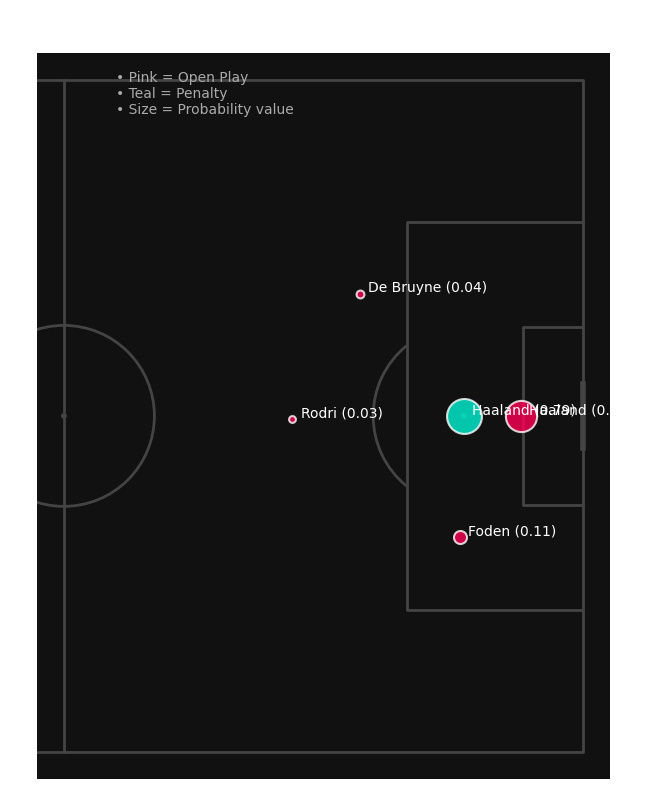

In [39]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt

# 1. Setup a horizontal half-pitch grid (focusing only on the attacking half)
pitch = Pitch(pitch_type='opta', half=True, pitch_color='#111111', line_color='#444444')
fig, ax = pitch.draw(figsize=(11, 8))

# 2. Loop through the dataset to plot each shot dynamically based on its xG size
for index, row in df_shots.iterrows():
    # Scale the circle size proportional to the calculated xG value
    circle_size = row['xG Score'] * 800

    # Choose color based on play type
    marker_color = '#00f5d4' if row['situation'] == 'Penalty' else '#ff0055'

    # Plot the shot location
    pitch.scatter(row['x'], row['y'], ax=ax, s=circle_size,
                  color=marker_color, edgecolors='white', alpha=0.8, linewidths=1.5)

    # Add the player name text next to their shot mark
    pitch.text(row['x'] + 0.8, row['y'] + 1, s=f"{row['player']} ({row['xG Score']})",
               ax=ax, color='white', fontsize=10, va='center')

# 3. Titles and Context
plt.title("Manchester City Match Shot Map & Expected Goals (xG)", color='white', fontsize=16, pad=20)
# Custom small legend text
ax.text(55, 95, "• Pink = Open Play\n• Teal = Penalty\n• Size = Probability value", color='#aaaaaa', fontsize=10)
plt.show()


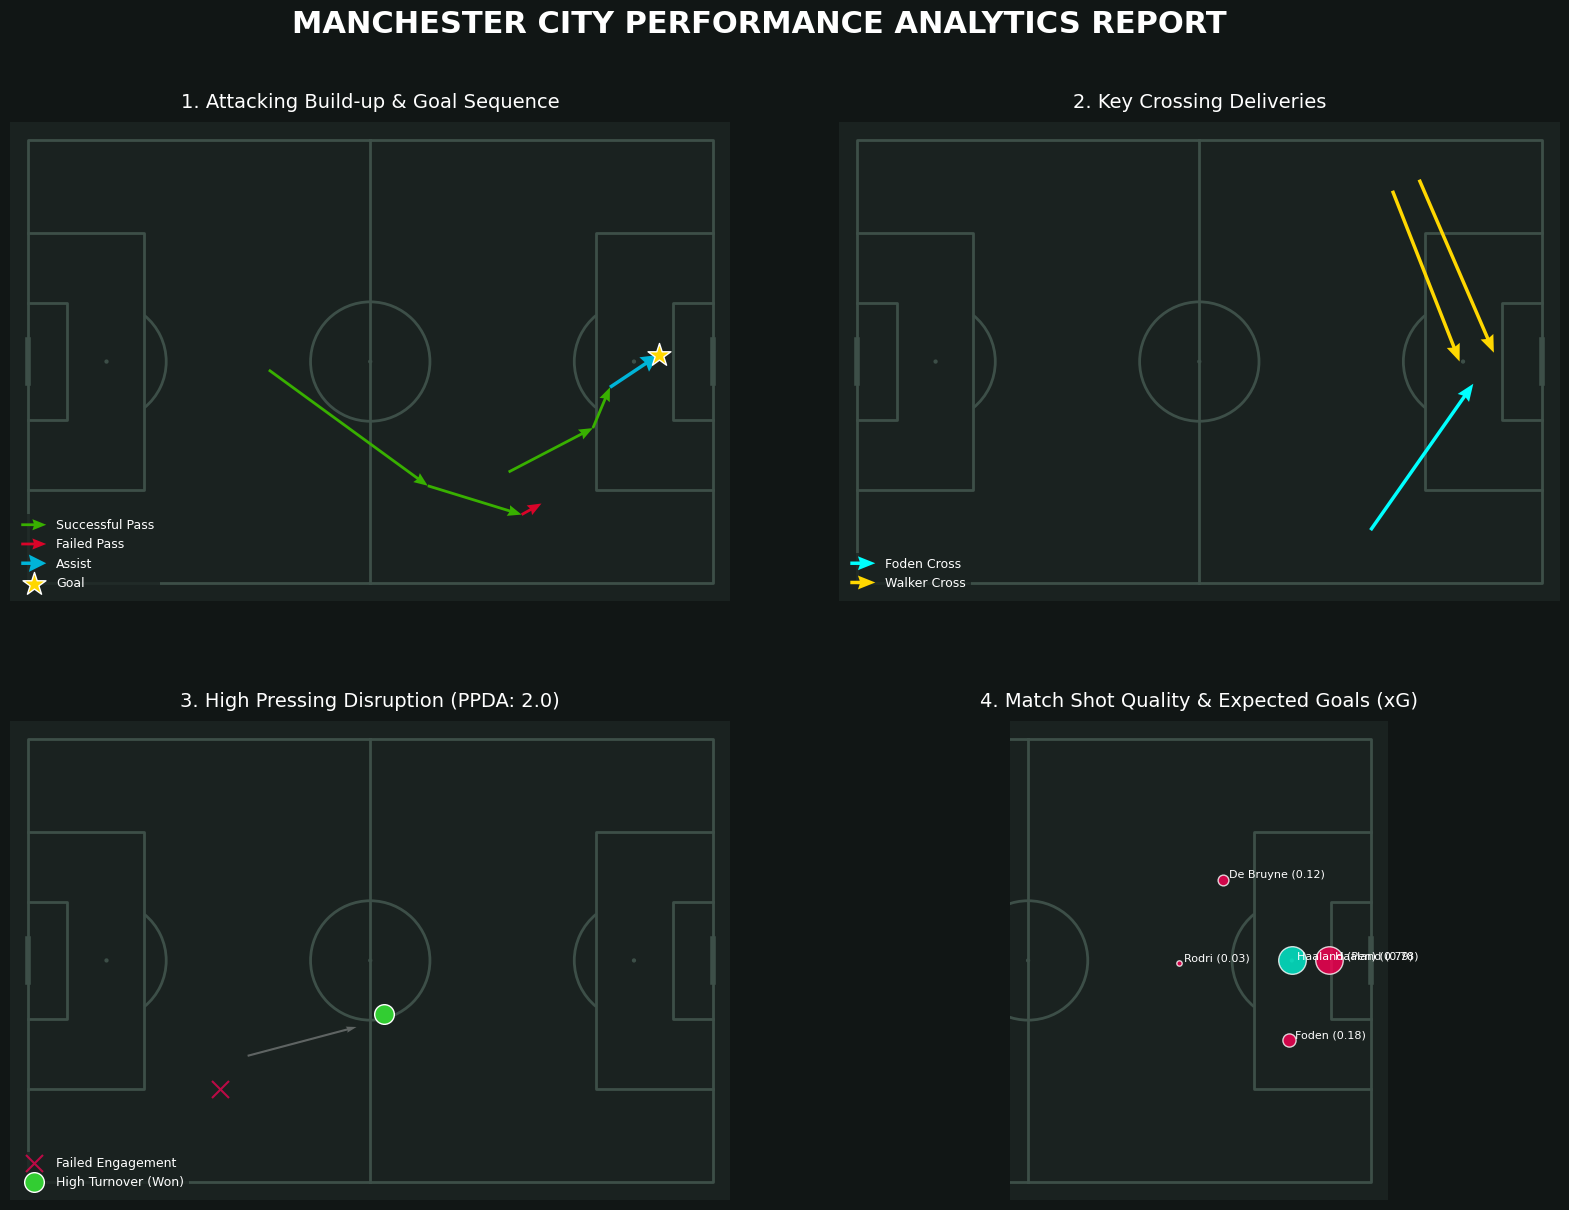

In [40]:
from mplsoccer import Pitch
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# -------------------------------------------------------------
# 1. SETUP THE GRID SYSTEM (2x2 Dashboard Layout)
# -------------------------------------------------------------
fig, axs = plt.subplots(2, 2, figsize=(20, 14), facecolor='#111615')
plt.subplots_adjust(wspace=0.15, hspace=0.25)

# Initialize standard Opta pitches across all 4 panels
pitch = Pitch(pitch_type='opta', pitch_color='#1a2220', line_color='#3d4f48')

# -------------------------------------------------------------
# PANEL 1 (TOP LEFT): ATTACKING BUILD-UP SEQUENCE
# -------------------------------------------------------------
pitch.draw(ax=axs[0, 0])
# Draw passing chains
pitch.arrows(35.2, 48.1, 58.4, 22.0, ax=axs[0, 0], width=2, headwidth=4, color='#38b000', label="Successful Pass")
pitch.arrows(58.4, 22.0, 72.1, 15.5, ax=axs[0, 0], width=2, headwidth=4, color='#38b000')
pitch.arrows(72.1, 15.5, 75.0, 18.0, ax=axs[0, 0], width=2, headwidth=4, color='#d90429', label="Failed Pass")
pitch.arrows(70.2, 25.1, 82.5, 35.0, ax=axs[0, 0], width=2, headwidth=4, color='#38b000')
pitch.arrows(82.5, 35.0, 85.0, 44.2, ax=axs[0, 0], width=2, headwidth=4, color='#38b000')
pitch.arrows(85.0, 44.2, 92.1, 51.5, ax=axs[0, 0], width=2.5, headwidth=5, color='#00b4d8', label="Assist")
pitch.scatter(92.1, 51.5, ax=axs[0, 0], color='gold', marker='*', s=300, edgecolors='white', zorder=5, label="Goal")

axs[0, 0].set_title("1. Attacking Build-up & Goal Sequence", color='white', fontsize=14, pad=10)
axs[0, 0].legend(loc='lower left', fontsize=9, facecolor='#1a2220', edgecolor='none', labelcolor='white')

# -------------------------------------------------------------
# PANEL 2 (TOP RIGHT): CROSSING CHANNELS
# -------------------------------------------------------------
pitch.draw(ax=axs[0, 1])
# Foden left flank cross
pitch.arrows(75.0, 12.0, 90.0, 45.0, ax=axs[0, 1], width=2.5, headwidth=4, color='cyan', label="Foden Cross")
# Walker right flank crosses
pitch.arrows(78.2, 88.5, 88.0, 50.0, ax=axs[0, 1], width=2.5, headwidth=4, color='gold', label="Walker Cross")
pitch.arrows(82.1, 91.0, 93.0, 52.0, ax=axs[0, 1], width=2.5, headwidth=4, color='gold')

axs[0, 1].set_title("2. Key Crossing Deliveries", color='white', fontsize=14, pad=10)
axs[0, 1].legend(loc='lower left', fontsize=9, facecolor='#1a2220', edgecolor='none', labelcolor='white')

# -------------------------------------------------------------
# PANEL 3 (BOTTOM LEFT): HIGH PRESSING DISRUPTION (PPDA)
# -------------------------------------------------------------
pitch.draw(ax=axs[1, 0])
# Failed press marker
pitch.scatter(28.0, 21.0, ax=axs[1, 0], color='#ff0055', marker='x', s=150, alpha=0.7, label="Failed Engagement")
# High Turnover marker
pitch.scatter(52.0, 38.0, ax=axs[1, 0], color='limegreen', marker='o', s=200, edgecolors='white', label="High Turnover (Won)")
# Arsenal escape attempt path
pitch.arrows(32.1, 28.5, 48.0, 35.0, ax=axs[1, 0], width=1.5, headwidth=3, color='white', linestyle='dashed', alpha=0.3)

axs[1, 0].set_title("3. High Pressing Disruption (PPDA: 2.0)", color='white', fontsize=14, pad=10)
axs[1, 0].legend(loc='lower left', fontsize=9, facecolor='#1a2220', edgecolor='none', labelcolor='white')

# -------------------------------------------------------------
# PANEL 4 (BOTTOM RIGHT): EXPECTED GOALS (xG) SHOT MAP
# -------------------------------------------------------------
# For a clean shot map dashboard look, we focus on the attacking half
pitch_half = Pitch(pitch_type='opta', half=True, pitch_color='#1a2220', line_color='#3d4f48')
pitch_half.draw(ax=axs[1, 1])

# Plotting the shots dynamically based on size
shots_to_plot = [
    {"x": 94.0, "y": 50.0, "xg": 0.78, "p": "Haaland"},
    {"x": 78.5, "y": 68.2, "xg": 0.12, "p": "De Bruyne"},
    {"x": 88.1, "y": 32.0, "xg": 0.18, "p": "Foden"},
    {"x": 88.5, "y": 50.0, "xg": 0.79, "p": "Haaland (Pen)"},
    {"x": 72.0, "y": 49.5, "xg": 0.03, "p": "Rodri"}
]

for s in shots_to_plot:
    size = s["xg"] * 500
    color = '#00f5d4' if "Pen" in s["p"] else '#ff0055'
    pitch_half.scatter(s["x"], s["y"], ax=axs[1, 1], s=size, color=color, edgecolors='white', alpha=0.8)
    pitch_half.text(s["x"] + 0.8, s["y"] + 1, s=f"{s['p']} ({s['xg']})", ax=axs[1, 1], color='white', fontsize=8, va='center')

axs[1, 1].set_title("4. Match Shot Quality & Expected Goals (xG)", color='white', fontsize=14, pad=10)

# -------------------------------------------------------------
# DASHBOARD HEADER SUPERSTRUCTURE
# -------------------------------------------------------------
plt.suptitle("MANCHESTER CITY PERFORMANCE ANALYTICS REPORT", color='white', fontsize=22, weight='bold', y=0.96)
plt.show()
